1 & 2. Total sale drugs each categories (ascending to descanding : 
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333 

3. drugs have the highest sales in January 2015, July 2016, September 2017
january 2015 N02BE    1044.24
July 2016 N02BE    652.362
September 2017 N02BE    863.75

4. Which drug has sold the most often in 2017?
N02BE    9258.804833

Which drug category has the highest average daily sales?
N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522

The category with the highest average is: N02BE (29.92)

Are respiratory drugs (R03) sold more during specific months?


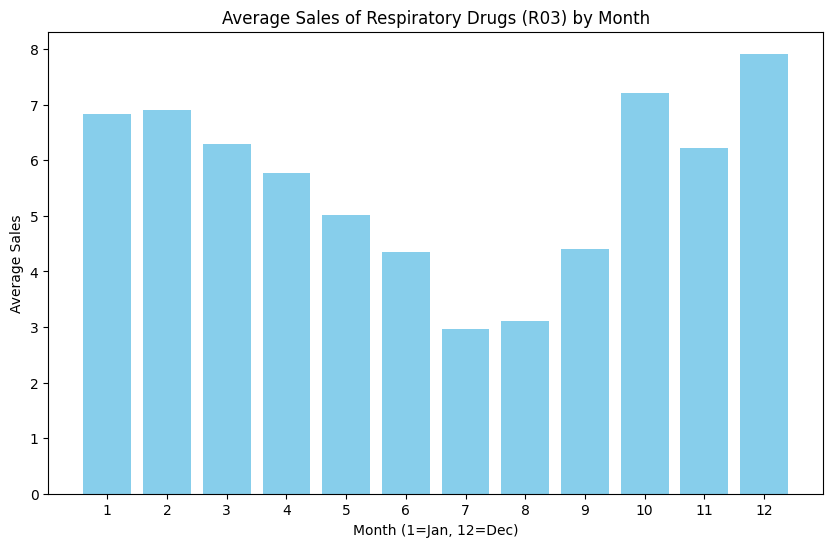

The highest average sales for R03 occurred in month12 dengan rata-rata 7.92


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

data = "/content/salesdaily.csv"
df = pd.read_csv(data)

df['datum'] = pd.to_datetime(df['datum'])
df['dateonly'] = df['datum'].dt.date

atc_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Q1 & Q2: Total Penjualan per Kategori (Urut dari terbesar)
# Logika: Tinggal jumlahkan (sum) kolom-komom kategori secara langsung.

sale_category = df[atc_cols].sum().sort_values(ascending=False)
print("1 & 2. Total sale drugs each categories (ascending to descanding : ")
print (sale_category.to_string(), "\n")

def highest_sales (year, month):
  filtered_df = df[(df['Year'] == year) & (df['Month'] == month)]
  return filtered_df[atc_cols].sum().nlargest(1)

print("3. drugs have the highest sales in January 2015, July 2016, September 2017")
print("january 2015", highest_sales(2015, 1).to_string())
print("July 2016", highest_sales(2016, 7).to_string())
print("September 2017", highest_sales(2017, 9).to_string())

print("")
print("4. Which drug has sold the most often in 2017?")
sales_2017 = df[df['Year'] == 2017][atc_cols].sum()
most_sold_2017 = sales_2017.nlargest(1)
print(most_sold_2017.to_string())

print("")
print("Which drug category has the highest average daily sales?")
average_daily = df[atc_cols].mean().sort_values(ascending=False)
print(average_daily.to_string())
print(f"\nThe category with the highest average is: {average_daily.idxmax()} ({average_daily.max():.2f})")

print("")
print("Are respiratory drugs (R03) sold more during specific months?")
monthly_r03 = df.groupby('Month')['R03'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(monthly_r03['Month'], monthly_r03['R03'], color='skyblue')
plt.title('Average Sales of Respiratory Drugs (R03) by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average Sales')
plt.xticks(monthly_r03['Month'])
plt.show()

#peak months
peak_month = monthly_r03.loc[monthly_r03['R03'].idxmax()]
print(f"The highest average sales for R03 occurred in month{int(peak_month['Month'])} dengan rata-rata {peak_month['R03']:.2f}")